Copyright Amazon.com, Inc. or its affiliates. All Rights Reserved.
SPDX-License-Identifier: Apache-2.0

MILLET Pipeline Example

In [1]:
"""
Initial config
"""
import os

# Navigate to correct directory
print(os.getcwd())
if os.getcwd().endswith("notebooks"):
    os.chdir("../")
print(os.getcwd())

# Setup auto reload of source code changes
%load_ext autoreload
%autoreload 2

d:\Documents\Intership TSC\millet_ecg\notebooks
d:\Documents\Intership TSC\millet_ecg


In [7]:
# Debug: Check the first 20 lines of the TS file
file_path = "data/ECG5000/ECG5000_TRAIN.ts"
with open(file_path, 'r') as f:
    for i, line in enumerate(f):
        if i < 20:
            print(f"Line {i}: {line[:100]}...")  # Print first 100 chars
        else:
            break

Line 0: #ECG5000 provenance not determined yet
...
Line 1: @problemName ECG5000
...
Line 2: @timeStamps false
...
Line 3: @missing false
...
Line 4: @univariate true
...
Line 5: @equalLength true
...
Line 6: @seriesLength 140
...
Line 7: @classLabel true 1 2 3 4 5
...
Line 8: @data
...
Line 9: -0.11252183,-2.8272038,-3.7738969,-4.3497511,-4.376041,-3.4749863,-2.1814082,-1.8182865,-1.2505219,-...
Line 10: -1.1008778,-3.9968398,-4.2858426,-4.5065789,-4.0223767,-3.2343676,-1.5661258,-0.99225766,-0.75467971...
Line 11: -0.56708802,-2.5934502,-3.8742297,-4.5840949,-4.1874487,-3.1514617,-1.7429402,-1.4906585,-1.1835803,...
Line 12: 0.49047253,-1.9144071,-3.6163638,-4.3188235,-4.2680158,-3.8811104,-2.9932802,-1.6711314,-1.3338845,-...
Line 13: 0.80023202,-0.87425189,-2.3847613,-3.9732924,-4.3382241,-3.8024222,-2.5345096,-1.7834233,-1.5944504,...
Line 14: -1.5076736,-3.57455,-4.4780109,-4.4082752,-3.3212415,-2.1051715,-1.4810482,-1.3013622,-0.4982396,-0....
Line 15: -0.297161,-2.7666349,-4.102

In [6]:
from millet.data.ecg5000_dataset import ECG5000Dataset

train_dataset = ECG5000Dataset("TRAIN")
test_dataset = ECG5000Dataset("TEST")
print("Train Size:", len(train_dataset))
print(" Test Size:", len(test_dataset))

Loaded 500 data rows from data/ECG5000/ECG5000_TRAIN.ts
Processed 500 valid samples for TRAIN split
Target classes present: tensor([0, 1, 2, 3, 4], dtype=torch.int32)
Loaded 4500 data rows from data/ECG5000/ECG5000_TEST.ts
Processed 4500 valid samples for TEST split
Target classes present: tensor([0, 1, 2, 3, 4], dtype=torch.int32)
Train Size: 500
 Test Size: 4500


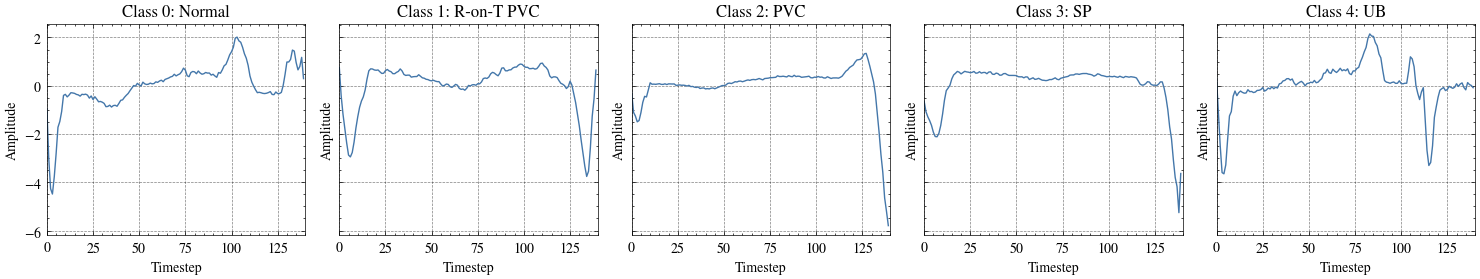

In [8]:
"""
Plot one example per class from ECG5000
"""
from matplotlib import pyplot as plt

# Need to keep scienceplots imported for matplotlib styling even though the import is never used directly
# noinspection PyUnresolvedReferences
import scienceplots

# Configure matplotlib style
plt.style.use(["science", "bright", "no-latex", "grid"])

# ECG5000 class names
ECG5000_CLZ_NAMES = ["Normal", "R-on-T PVC", "PVC", "SP", "UB"]

def plot_ecg5000_examples(dataset):
    _, axes = plt.subplots(nrows=1, ncols=5, figsize=(15, 3), sharex=True, sharey=True)
    for clz in range(dataset.n_clz):
        # Get a random example for this class
        idx_clz = dataset.get_n_idxs(1, clz=clz, shuffle=True)
        ts = dataset.get_bag(idx_clz)
        # Plot time series
        axis = axes[clz]
        axis.plot(ts)
        axis.set_xlim(0, len(ts))
        axis.set_title("Class {:d}: {:s}".format(clz, ECG5000_CLZ_NAMES[clz]))
        axis.set_xlabel("Timestep")
        axis.set_ylabel("Amplitude")

plot_ecg5000_examples(train_dataset)
plt.tight_layout()
plt.show()

In [16]:
"""
Analyze current data distribution
"""
from collections import Counter
import numpy as np

def analyze_data_distribution(train_dataset, test_dataset, class_names):
    train_targets = train_dataset.targets.numpy()
    test_targets = test_dataset.targets.numpy()
    
    print("="*60)
    print("DATA DISTRIBUTION ANALYSIS")
    print("="*60)
    
    print("\nTraining Set (500 samples):")
    train_counts = Counter(train_targets)
    for c in range(5):
        count = train_counts.get(c, 0)
        pct = 100 * count / len(train_targets)
        bar = "█" * int(pct / 2)
        print(f"  Class {c} ({class_names[c]:12s}): {count:3d} samples ({pct:5.1f}%) {bar}")
    
    print("\nTest Set (4500 samples):")
    test_counts = Counter(test_targets)
    for c in range(5):
        count = test_counts.get(c, 0)
        pct = 100 * count / len(test_targets)
        bar = "█" * int(pct / 2)
        print(f"  Class {c} ({class_names[c]:12s}): {count:4d} samples ({pct:5.1f}%) {bar}")
    
    # Identify minority classes
    print("\nMinority Classes (need augmentation):")
    for c in range(5):
        if train_counts.get(c, 0) < 100:
            print(f"    Class {c} ({class_names[c]}): Only {train_counts.get(c, 0)} training samples")

analyze_data_distribution(train_dataset, test_dataset, ECG5000_CLZ_NAMES)

DATA DISTRIBUTION ANALYSIS

Training Set (500 samples):
  Class 0 (Normal      ): 292 samples ( 58.4%) █████████████████████████████
  Class 1 (R-on-T PVC  ): 177 samples ( 35.4%) █████████████████
  Class 2 (PVC         ):  10 samples (  2.0%) █
  Class 3 (SP          ):  19 samples (  3.8%) █
  Class 4 (UB          ):   2 samples (  0.4%) 

Test Set (4500 samples):
  Class 0 (Normal      ): 2627 samples ( 58.4%) █████████████████████████████
  Class 1 (R-on-T PVC  ): 1590 samples ( 35.3%) █████████████████
  Class 2 (PVC         ):   86 samples (  1.9%) 
  Class 3 (SP          ):  175 samples (  3.9%) █
  Class 4 (UB          ):   22 samples (  0.5%) 

Minority Classes (need augmentation):
    Class 2 (PVC): Only 10 training samples
    Class 3 (SP): Only 19 training samples
    Class 4 (UB): Only 2 training samples


In [10]:
"""
Construct a model and train it
"""
from millet.model import backbone
from millet.model import pooling
from millet.model.millet_model import MILLETModel
from millet.util import get_gpu_device_for_os

from torch import nn
import os


# Example network
class ExampleNet(nn.Module):
    def __init__(self, feature_extractor, pool):
        super().__init__()
        self.feature_extractor = feature_extractor
        self.pool = pool

    def forward(self, bags, pos=None):
        timestep_embeddings = self.feature_extractor(bags)
        return self.pool(timestep_embeddings, pos=pos)


# Get GPU enabled device depending on operating system
device = get_gpu_device_for_os()

# Univariate dataset so 1 channel
n_channels = 1

# Pooling config
d_in = 128  # Output size of feature extractor
n_clz = train_dataset.n_clz  # 5 classes for ECG5000
dropout = 0.1
apply_positional_encoding = True

# Create network using InceptionTime feature extractor and Conjunctive Pooling
net = ExampleNet(
    backbone.InceptionTimeFeatureExtractor(n_channels),
    pooling.MILConjunctivePooling(
        d_in,
        n_clz,
        dropout=dropout,
        apply_positional_encoding=apply_positional_encoding,
    ),
)

# Create wrapper around net for training, evaluation, etc.
model = MILLETModel("ExampleNet_ECG5000", device, n_clz, net)

# Set to True to train (first time), False to load saved weights
train_model = True
if train_model:
    print("Starting training...")
    model.fit(train_dataset, n_epochs=1500)
    # Create directory if it doesn't exist
    os.makedirs("model/ECG5000", exist_ok=True)
    model.save_weights("model/ECG5000/ExampleNet.pth")
    print("Training complete and model saved!")
else:
    model.load_weights("model/ECG5000/ExampleNet.pth")
    print("Model loaded from saved weights!")

Starting training...
Training model: 100%|██████████| 1500/1500 [1:13:49<00:00,  2.95s/it]
Saving model to model/ECG5000/ExampleNet.pth
Training complete and model saved!


In [14]:
"""
Evaluate model (Standard Metrics Only)
"""
from texttable import Texttable
import latextable

# Evaluate predictive performance on train and test splits
train_results_dict = model.evaluate(train_dataset)
test_results_dict = model.evaluate(test_dataset)

# Skip interpretability metrics for ECG5000 (no ground truth regions)
# train_aopcr, train_ndcg = model.evaluate_interpretability(train_dataset)
# test_aopcr, test_ndcg = model.evaluate_interpretability(test_dataset)

header = ["Split", "Accuracy", "AUROC", "Loss"]
train_row = [
    "Train",
    train_results_dict["acc"],
    train_results_dict["auroc"],
    train_results_dict["loss"],
]
test_row = [
    "Test",
    test_results_dict["acc"],
    test_results_dict["auroc"],
    test_results_dict["loss"],
]

results_data = [header, train_row, test_row]

table = Texttable()
table.add_rows(results_data)
table.set_cols_align(["l"] * len(results_data[0]))
table.set_max_width(0)
print("\n-- Results --")
print(table.draw())


-- Results --
+-------+----------+-------+-------+
| Split | Accuracy | AUROC | Loss  |
+=======+==========+=======+=======+
| Train | 1        | 1     | 0.000 |
+-------+----------+-------+-------+
| Test  | 0.938    | 0.909 | 0.670 |
+-------+----------+-------+-------+


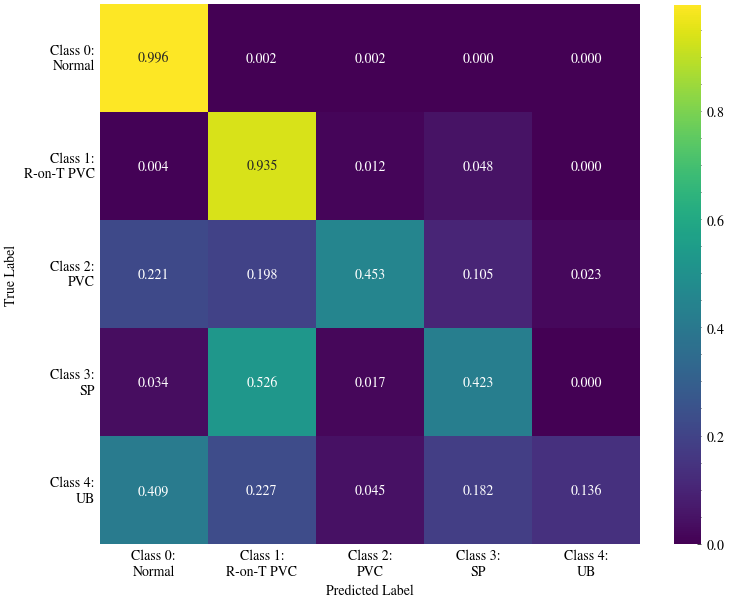

In [15]:
"""
Plot confusion matrix
"""

import seaborn as sns
import torch
from torch.nn.functional import normalize

# ECG5000 class names
ECG5000_CLZ_NAMES = ["Normal", "R-on-T PVC", "PVC", "SP", "UB"]

def plot_conf_mat(conf_mat):
    _, axis = plt.subplots(nrows=1, ncols=1, figsize=(8, 8))
    norm_conf_mat = normalize(conf_mat, p=1, dim=1)
    sns.heatmap(
        norm_conf_mat,
        ax=axis,
        fmt=".3f",
        cmap="viridis",
        cbar_kws={"shrink": 0.7},
        vmin=0,
        vmax=torch.max(norm_conf_mat),
        annot=True,
    )
    axis.set_aspect("equal")
    axis.tick_params(
        axis="x",
        which="both",
        top=False,
        bottom=False,
        labeltop=False,
        labelbottom=True,
    )
    axis.tick_params(
        axis="y",
        which="both",
        left=False,
        right=False,
        labelleft=True,
        labelright=False,
        labelrotation=0,
    )
    tick_labels = [
        "Class {:d}:\n{:s}".format(idx, clz_name) for idx, clz_name in enumerate(ECG5000_CLZ_NAMES)
    ]
    axis.set_xticklabels(tick_labels)
    axis.set_yticklabels(tick_labels)
    axis.set_xlabel("Predicted Label")
    axis.set_ylabel("True Label")

plot_conf_mat(test_results_dict["conf_mat"])
plt.tight_layout()
plt.show()

In [17]:
"""
Interpretability Analysis for ECG5000
"""
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ECG5000 class names
ECG5000_CLZ_NAMES = ["Normal", "R-on-T PVC", "PVC", "SP", "UB"]

def get_interpretation_for_sample(model, dataset, idx):
    """
    Get interpretation scores for a single sample.
    
    Returns:
        bag: The time series data
        true_label: Ground truth label
        pred_label: Predicted label
        pred_proba: Prediction probabilities for all classes
        interpretations: Interpretation scores for all classes (shape: n_classes x timesteps)
    """
    bag = dataset.get_bag(idx)
    true_label = dataset.get_target(idx)
    
    model_out = model(bag)
    bag_logits = model_out["bag_logits"]
    pred_proba = torch.softmax(bag_logits, dim=0).detach().cpu().numpy()
    pred_label = torch.argmax(bag_logits).item()
    
    # Get interpretation scores for all classes
    interpretations = model.interpret(model_out).detach().cpu().numpy()
    
    return {
        'bag': bag.squeeze().numpy(),
        'true_label': true_label,
        'pred_label': pred_label,
        'pred_proba': pred_proba,
        'interpretations': interpretations
    }


def plot_interpretation_detail(result, class_names, save_path=None):
    """
    Create a detailed interpretability visualization for a single sample.
    """
    bag = result['bag']
    true_label = result['true_label']
    pred_label = result['pred_label']
    pred_proba = result['pred_proba']
    interpretations = result['interpretations']
    
    n_classes = len(class_names)
    
    fig, axes = plt.subplots(nrows=2, ncols=n_classes, figsize=(4*n_classes, 6))
    
    # Find global min/max for consistent color scaling across all classes
    vmin = interpretations.min()
    vmax = interpretations.max()
    vmax = max(abs(vmin), abs(vmax))
    vmin, vmax = -vmax, vmax
    
    for c in range(n_classes):
        # Top row: Time series with interpretation heatmap overlay
        ax1 = axes[0, c]
        ax2 = axes[1, c]
        
        # Plot the ECG signal
        ax1.plot(bag, 'k-', linewidth=0.8, label='ECG Signal')
        
        # Create heatmap background using interpretation scores
        x = np.arange(len(bag))
        interp = interpretations[c]
        
        # Normalize scores for colormap
        norm = plt.Normalize(vmin, vmax)
        
        # Create colored background using pcolormesh
        X, Y = np.meshgrid(x, np.linspace(bag.min(), bag.max(), 2))
        C = np.tile(interp, (2, 1))
        
        im = ax1.pcolormesh(X, Y, C, cmap='RdBu_r', alpha=0.4, 
                           shading='auto', norm=norm, zorder=1)
        
        ax1.set_xlim(0, len(bag))
        ax1.set_ylim(bag.min() - 0.1, bag.max() + 0.1)
        ax1.set_xlabel('Timestep')
        ax1.set_ylabel('Amplitude')
        
        # Add prediction info
        color = 'green' if c == pred_label else 'red' if c == true_label else 'black'
        title = f"Class {c}: {class_names[c]}\n"
        title += f"Prob: {pred_proba[c]:.3f}"
        if c == true_label:
            title += " (True)"
        if c == pred_label:
            title += " (Predicted)"
        ax1.set_title(title, color=color)
        
        # Bottom row: Interpretation score bar plot
        colors = ['red' if v < 0 else 'blue' for v in interp]
        ax2.bar(x, interp, width=1.0, color=colors, alpha=0.7)
        ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        ax2.set_xlim(0, len(bag))
        ax2.set_xlabel('Timestep')
        ax2.set_ylabel('Importance Score')
        ax2.set_title(f'Interpretation Scores (Class {c})')
        
        # Add zero line and limits
        ax2.set_ylim(vmin, vmax)
    
    # Add colorbar
    fig.subplots_adjust(right=0.92)
    cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Evidence For (Blue) / Against (Red)')
    
    status = "✓ CORRECT" if true_label == pred_label else "✗ INCORRECT"
    fig.suptitle(f'Sample Interpretation - Prediction: {status}', 
                 fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    return fig


def plot_top_important_regions(result, class_names, top_k=3):
    """
    Highlight the top-k most important regions for each class.
    """
    bag = result['bag']
    interpretations = result['interpretations']
    n_classes = len(class_names)
    
    fig, axes = plt.subplots(1, n_classes, figsize=(4*n_classes, 3))
    if n_classes == 1:
        axes = [axes]
    
    for c in range(n_classes):
        ax = axes[c]
        interp = interpretations[c]
        
        # Plot ECG signal
        ax.plot(bag, 'k-', linewidth=0.8)
        
        # Find top-k positive peaks (evidence FOR this class)
        from scipy.signal import find_peaks
        
        # Positive peaks (supporting evidence)
        peaks_pos, _ = find_peaks(interp, height=0, distance=5)
        peak_values = interp[peaks_pos]
        top_k_pos = peaks_pos[np.argsort(peak_values)[-top_k:]]
        
        # Negative peaks (opposing evidence)
        peaks_neg, _ = find_peaks(-interp, height=0, distance=5)
        peak_values_neg = -interp[peaks_neg]
        top_k_neg = peaks_neg[np.argsort(peak_values_neg)[-top_k:]]
        
        # Highlight important regions
        for peak in top_k_pos:
            ax.axvspan(max(0, peak-3), min(len(bag)-1, peak+3), 
                      alpha=0.3, color='blue', label='Supporting' if peak == top_k_pos[0] else '')
        for peak in top_k_neg:
            ax.axvspan(max(0, peak-3), min(len(bag)-1, peak+3), 
                      alpha=0.3, color='red', label='Opposing' if peak == top_k_neg[0] else '')
        
        ax.set_xlim(0, len(bag))
        ax.set_title(f"{class_names[c]}")
        ax.set_xlabel("Timestep")
        ax.set_ylabel("Amplitude")
        
        if c == 0:
            ax.legend(loc='upper right', fontsize=8)
    
    true_label = result['true_label']
    pred_label = result['pred_label']
    status = "✓ Correct" if true_label == pred_label else "✗ Incorrect"
    fig.suptitle(f'Top Important Regions - {status}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


def analyze_class_interpretations(model, dataset, class_names, samples_per_class=2):
    """
    Analyze and visualize interpretations for multiple samples from each class.
    """
    for clz in range(len(class_names)):
        print(f"\n{'='*60}")
        print(f"Class {clz}: {class_names[clz]}")
        print('='*60)
        
        # Get indices for this class
        idxs = dataset.get_n_idxs(samples_per_class, clz=clz, shuffle=True)
        
        for i, idx in enumerate(idxs):
            idx_val = idx.item() if torch.is_tensor(idx) else idx
            result = get_interpretation_for_sample(model, dataset, idx_val)
            
            print(f"\n--- Sample {i+1} (Index: {idx_val}) ---")
            print(f"True: {class_names[result['true_label']]}, Pred: {class_names[result['pred_label']]}")
            print(f"Probabilities: ", end="")
            for c, prob in enumerate(result['pred_proba']):
                print(f"{class_names[c][:4]}: {prob:.3f}  ", end="")
            print()
            
            # Show detailed plot
            plot_interpretation_detail(result, class_names)
            
            # Show top regions plot
            plot_top_important_regions(result, class_names, top_k=3)

Found 5 correctly classified samples

Analyzing sample index: 0
True class: Normal
Predicted class: Normal


C:\Users\HP\AppData\Local\Temp\ipykernel_22412\608953110.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_22412\608953110.py:120: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) STIXGeneral.
  plt.tight_layout()
c:\Users\HP\anaconda3\envs\torch_gpu1\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) STIXGeneral.
  fig.canvas.print_figure(bytes_io, **kw)


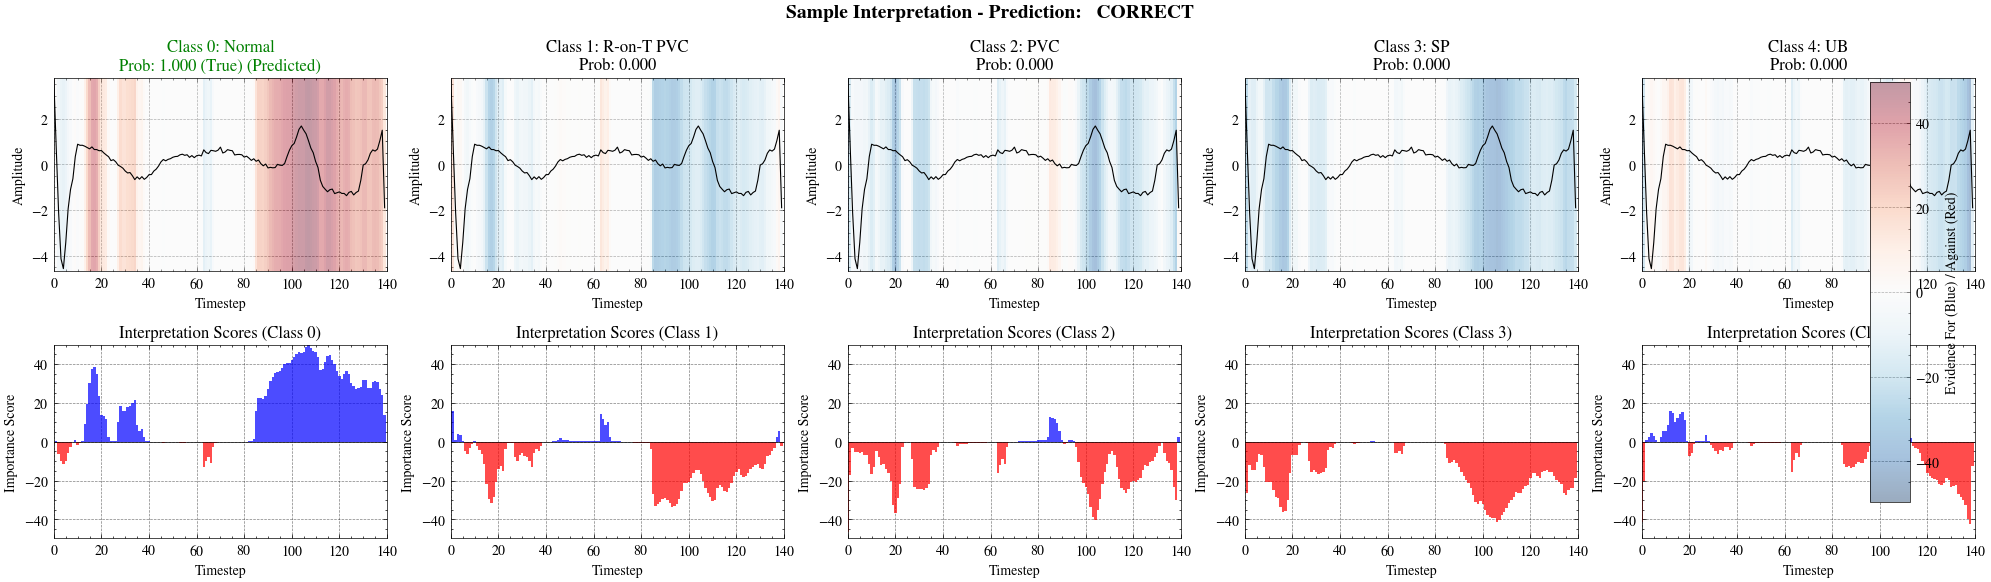

C:\Users\HP\AppData\Local\Temp\ipykernel_22412\608953110.py:180: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) STIXGeneral.
  plt.tight_layout()


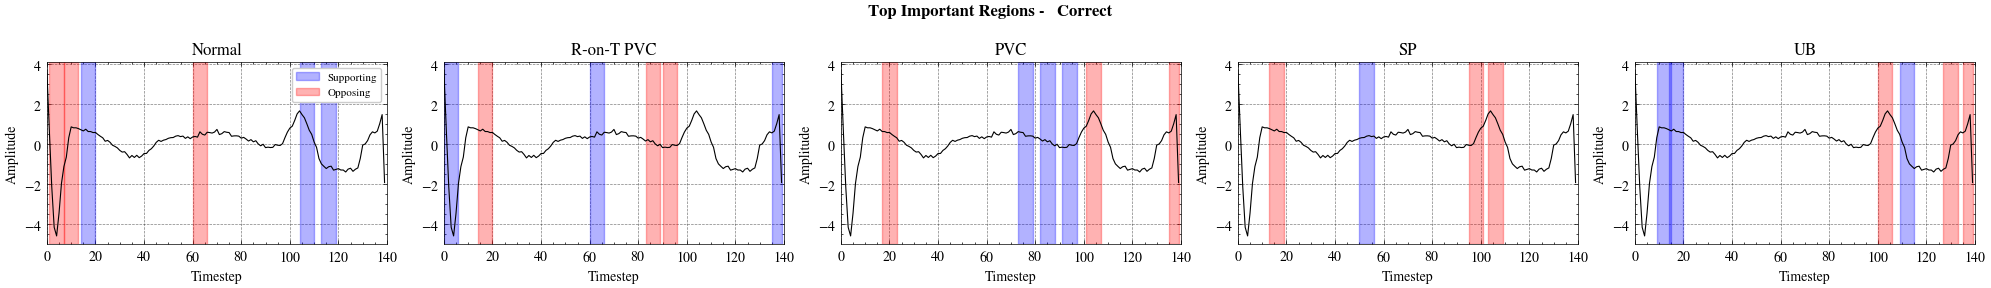

In [18]:
"""
Analyze a Correctly Classified Sample
"""
# Find a correctly classified sample from the test set
correct_idxs = []
for idx in range(len(test_dataset)):
    bag = test_dataset[idx]["bag"]
    model_out = model(bag)
    pred = torch.argmax(model_out["bag_logits"]).item()
    true = test_dataset.get_target(idx)
    if pred == true:
        correct_idxs.append(idx)
        if len(correct_idxs) >= 5:
            break

print(f"Found {len(correct_idxs)} correctly classified samples")

# Analyze the first correct sample
sample_idx = correct_idxs[0]
result = get_interpretation_for_sample(model, test_dataset, sample_idx)

print(f"\nAnalyzing sample index: {sample_idx}")
print(f"True class: {ECG5000_CLZ_NAMES[result['true_label']]}")
print(f"Predicted class: {ECG5000_CLZ_NAMES[result['pred_label']]}")

# Show detailed interpretation
plot_interpretation_detail(result, ECG5000_CLZ_NAMES)
plot_top_important_regions(result, ECG5000_CLZ_NAMES, top_k=3)

In the above diagram, we analyse time series for Class 8 (Peak).

The left column shows a correct example, where the model's prediction is correct and the discriminatory region (the peak) is identified.
The middle column shows an example where the model's prediction is incorrect, but the discriminatory region is still somewhat identifiable from the interpretation.
The right column shows an example where the prediction is incorrect and the discriminatory region is not identified.

The first two sets of heatmaps (rows 4 and 5) visualise the interpretation scores, where scores below zero are in red and scores above zero are in their class colour (purple for class 0 and green for class 8). The strength of the colour indicates the absolute value, i.e. scores near zero are white, and scores far from zero are dark red (refuting) or dark purple/green (supporting).

The final set of heatmaps (row 6) is a combined heatmap across both classes, where the maximal class for each timestep is chosen as the positive colour.

In [ ]:


# %% [markdown]
# # Stage 1: Setup and Data Loading
# 
# Let's start by setting up our environment and loading the ECG5000 dataset.
# ECG5000 contains 5 classes of heartbeat patterns:
# - Class 0: Normal
# - Class 1: R-on-T PVC (Premature Ventricular Contraction)
# - Class 2: PVC
# - Class 3: SP (Supraventricular Premature)
# - Class 4: UB (Unclassifiable Beat)

# %%
"""
INITIAL SETUP
- Navigate to correct directory
- Enable auto-reload for development
"""
import os
import sys
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from matplotlib import pyplot as plt
import seaborn as sns
from collections import Counter
from texttable import Texttable

# Navigate to project root
print(f"Current directory: {os.getcwd()}")
if os.getcwd().endswith("notebooks"):
    os.chdir("../")
print(f"Working directory: {os.getcwd()}")

# Auto-reload for development
%load_ext autoreload
%autoreload 2

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Configure matplotlib for better visuals
plt.style.use(["science", "bright", "no-latex", "grid"])
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 11


DATA DISTRIBUTION ANALYSIS

Training Set (500 samples):
  Class 0 (Normal      ): 292 samples ( 58.4%) █████████████████████████████
  Class 1 (R-on-T PVC  ): 177 samples ( 35.4%) █████████████████
  Class 2 (PVC         ):  10 samples (  2.0%) █
  Class 3 (SP          ):  19 samples (  3.8%) █
  Class 4 (UB          ):   2 samples (  0.4%) 

Test Set (4500 samples):
  Class 0 (Normal      ): 2627 samples ( 58.4%) █████████████████████████████
  Class 1 (R-on-T PVC  ): 1590 samples ( 35.3%) █████████████████
  Class 2 (PVC         ):   86 samples (  1.9%) 
  Class 3 (SP          ):  175 samples (  3.9%) █
  Class 4 (UB          ):   22 samples (  0.5%) 

Minority Classes (need augmentation):
    Class 2 (PVC): Only 10 training samples
    Class 3 (SP): Only 19 training samples
    Class 4 (UB): Only 2 training samples
